# Online Retail Analytics

## Customer Segmentation Using K-Means Clustering

### Objective

This notebook applies Machine Learning (K-Means Clustering) to identify natural customer groups based on purchasing behavior.

### Business Goals

- Discover hidden customer segments
- Identify high-value and low-value customer groups
- Support personalized marketing strategies
- Improve customer retention and business decision-making

In [8]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [9]:
DATA_PATH = Path("../data/processed/cleaned_online_retail.csv")

df = pd.read_csv(DATA_PATH)

In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = df["Quantity"] * df["Price"]

In [12]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [13]:
customer_features = (
    df.groupby("Customer ID")
      .agg(
          Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
          Frequency=("Invoice", "nunique"),
          Monetary=("TotalPrice", "sum")
      )
      .reset_index()
)

customer_features.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [7]:
customer_features.describe().round(2)

,Customer ID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,2955.90
std,1715.57,209.34,13.01,14440.85
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,342.28
50%,15314.50,96.00,3.00,867.74
75%,16797.75,380.00,7.00,2248.30
max,18287.00,739.00,398.00,580987.04


# Step 6 — Feature Scaling

## Business Question

Why should customer features be scaled before clustering?

Customer features such as Recency, Frequency, and Monetary have different ranges.

For example:
- Recency may range from 1 to 365 days.
- Frequency may range from 1 to 200 orders.
- Monetary may range from $10 to over $100,000.

Without scaling, features with larger values would dominate the clustering process.

Standardization ensures that each feature contributes equally to the K-Means algorithm.

In [14]:
features = customer_features[
    ["Recency", "Frequency", "Monetary"]
]

features.head()

,Recency,Frequency,Monetary
0,326,12,77556.46
1,2,8,4921.53
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [16]:
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df.head()

,Recency,Frequency,Monetary
0,0.595584,0.438998,5.166378
1,-0.952279,0.131502,0.136127
2,-0.603532,-0.099120,-0.064857
3,-0.871064,-0.175994,0.101996
4,0.519146,-0.406616,-0.181549


In [17]:
scaled_df.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-0.96,-0.41,-0.20
25%,-0.84,-0.41,-0.18
50%,-0.50,-0.25,-0.14
75%,0.85,0.05,-0.05
max,2.57,30.11,40.03


# Step 7 — Finding the Optimal Number of Clusters

## Business Question

How many customer segments should be created?

The Elbow Method helps determine the optimal number of clusters by measuring
how the clustering error changes as the number of clusters increases.

The best number of clusters is usually found at the "elbow" point,
where additional clusters provide diminishing improvements.

In [19]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

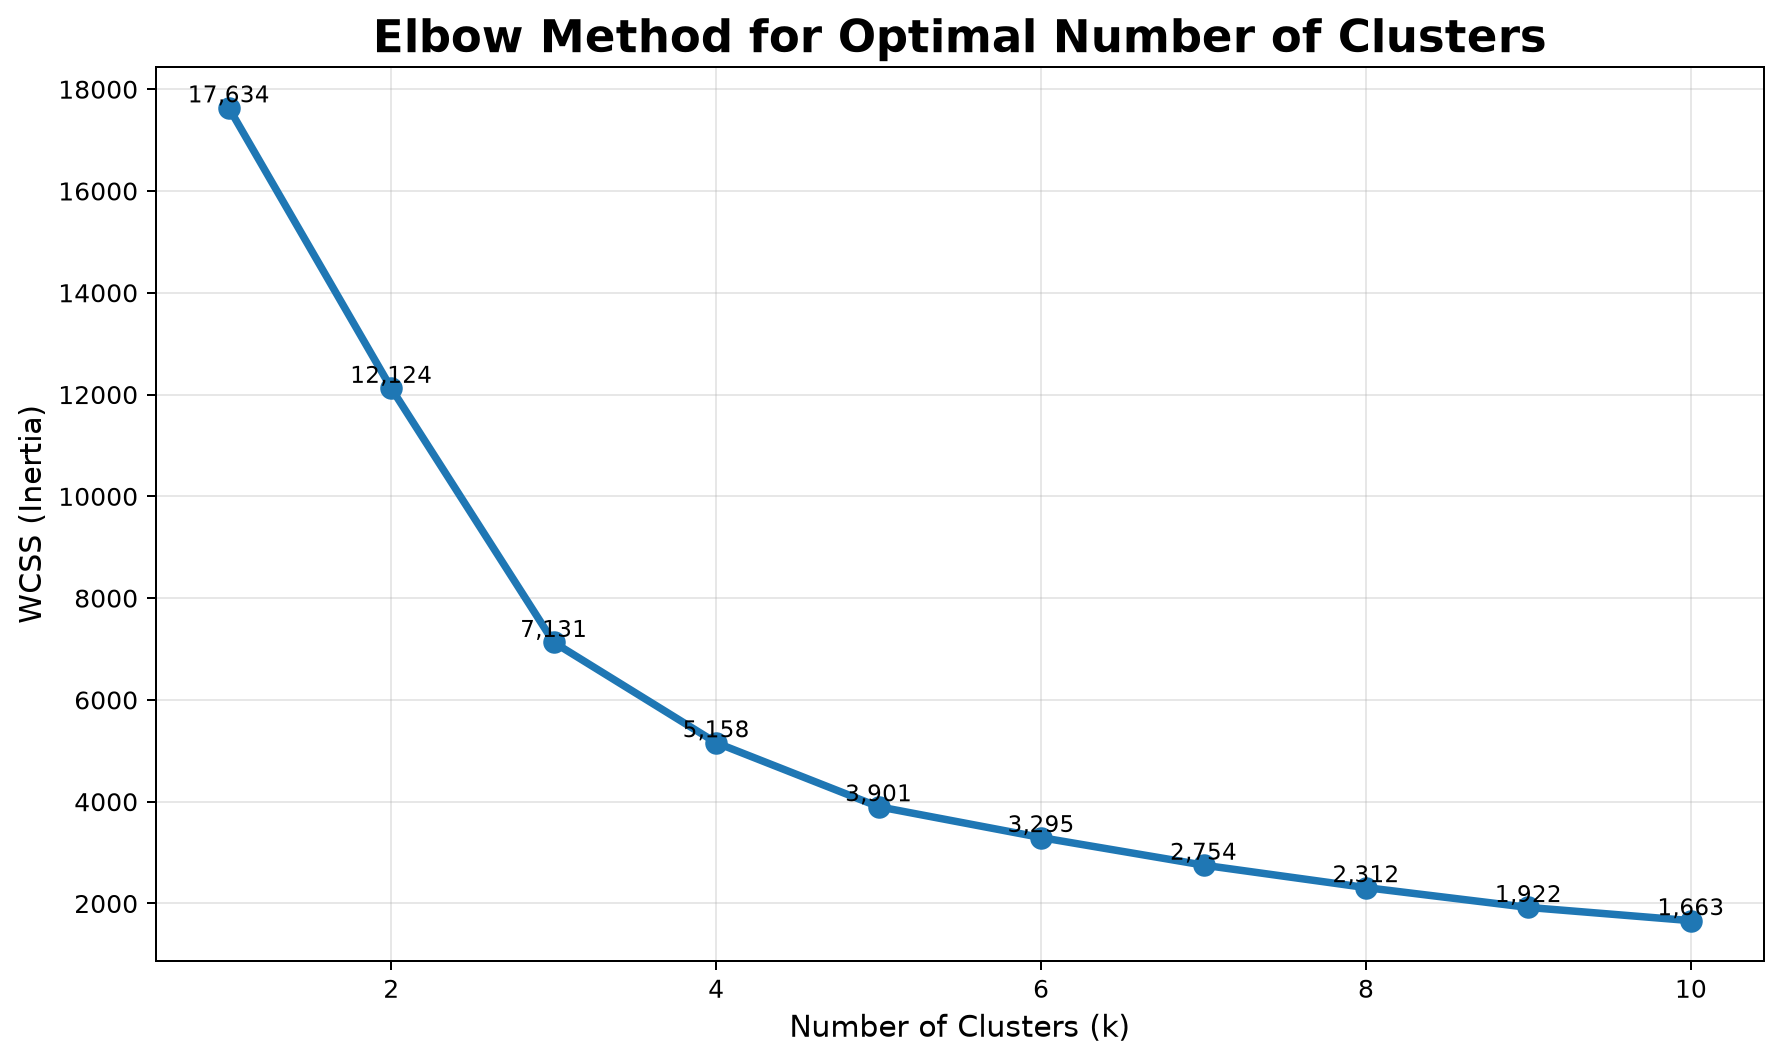

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)

ax.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=3,
    markersize=8
)

for x, y in zip(range(1, 11), wcss):
    ax.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Number of Clusters (k)", fontsize=12)
ax.set_ylabel("WCSS (Inertia)", fontsize=12)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

The Elbow Method evaluates how clustering performance changes as the number of clusters increases.

A noticeable bend ("elbow") in the curve suggests the optimal number of customer segments. Beyond this point, adding more clusters results in only minor improvements while increasing model complexity.

# Step 8 — Train the K-Means Model

## Business Question

Can Machine Learning identify natural customer groups based on purchasing behavior?

Using the optimal number of clusters determined by the Elbow Method, the K-Means algorithm groups customers with similar purchasing patterns.

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = kmeans.fit_predict(scaled_df)

customer_features.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,0
1,12347.0,2,8,4921.53,0
2,12348.0,75,5,2019.40,0
3,12349.0,19,4,4428.69,0
4,12350.0,310,1,334.40,1


# Step 9 — Visualizing Customer Clusters

## Business Question

How are the discovered customer clusters distributed?

Principal Component Analysis (PCA) reduces the three customer features into two dimensions, allowing the clusters to be visualized clearly.

In [22]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_df)

customer_features["PCA1"] = pca_features[:, 0]
customer_features["PCA2"] = pca_features[:, 1]

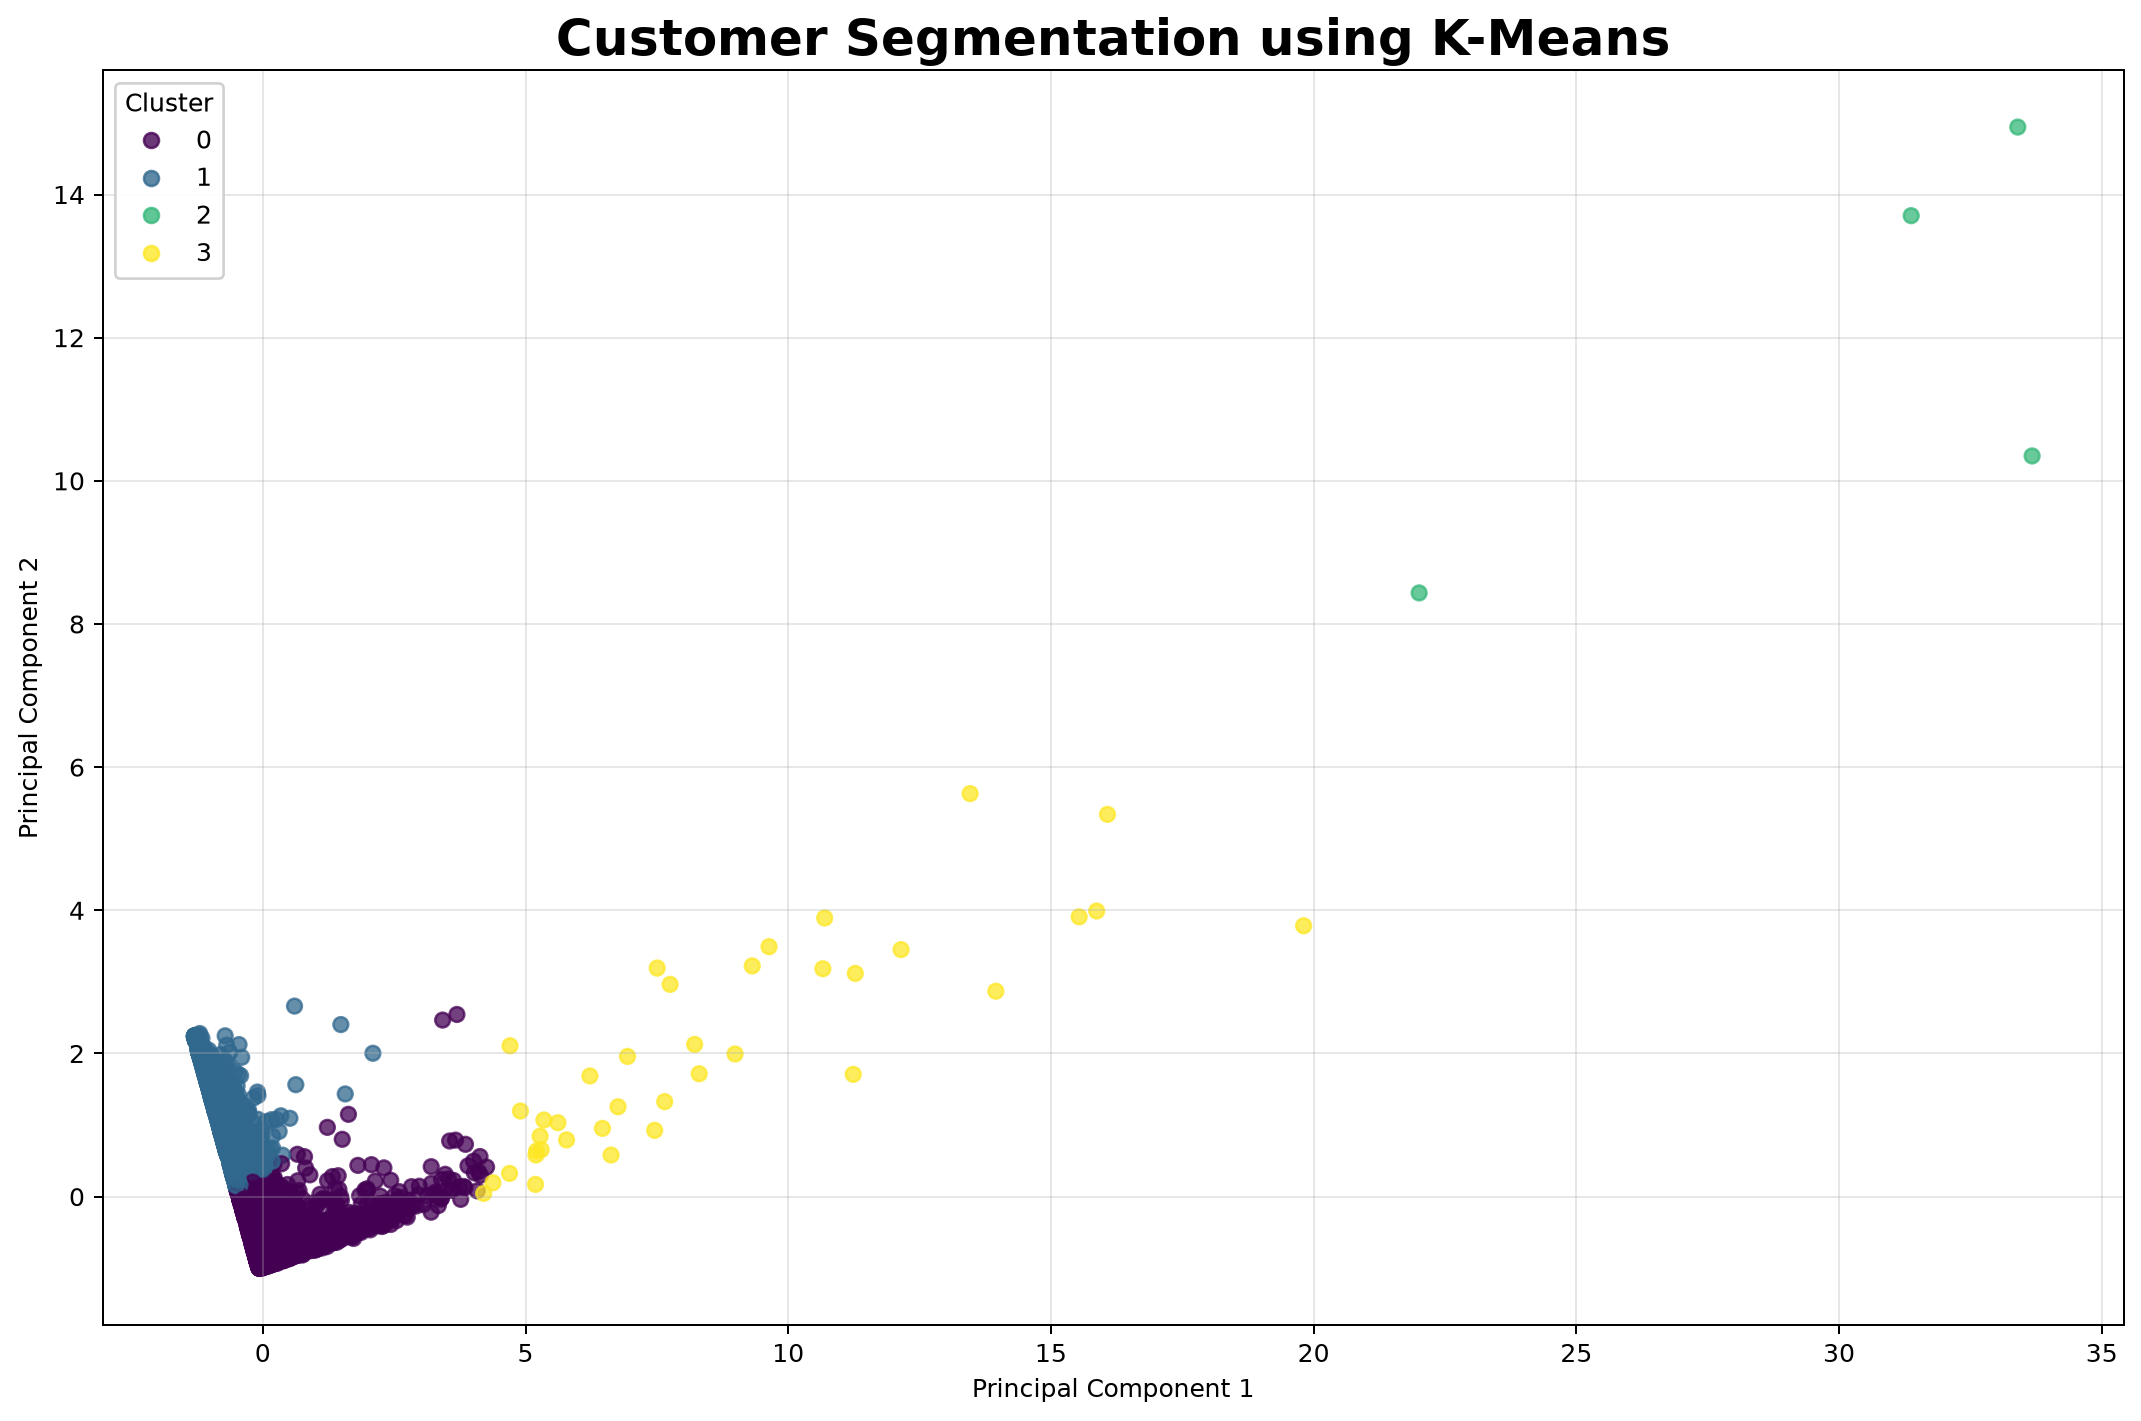

In [23]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=180)

scatter = ax.scatter(
    customer_features["PCA1"],
    customer_features["PCA2"],
    c=customer_features["Cluster"],
    cmap="viridis",
    s=35,
    alpha=0.75
)

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

ax.add_artist(legend)

ax.set_title(
    "Customer Segmentation using K-Means",
    fontsize=20,
    fontweight="bold"
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

ax.grid(alpha=.30)

plt.tight_layout()

plt.show()

# Step 10 — Cluster Profile

## Business Question

How does each cluster differ in customer behavior?

The table below summarizes each cluster using the average values of Recency, Frequency, and Monetary.

In [24]:
cluster_profile = (
    customer_features
    .groupby("Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,67.05,7.27,2921.08
1,463.03,2.21,748.54
2,3.50,212.50,428612.00
3,24.26,100.13,77728.27


# Step 11 — Business-Friendly Cluster Names

## Business Question

How can machine learning clusters be translated into meaningful business segments?

The numeric cluster IDs are mapped to descriptive names based on customer purchasing behavior, making the results easier for business stakeholders to interpret and act upon.

In [25]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

customer_features["Segment"] = (
    customer_features["Cluster"]
    .map(cluster_names)
)

In [26]:
customer_features[
    ["Customer ID", "Cluster", "Segment"]
].head(10)

,Customer ID,Cluster,Segment
0,12346.0,0,Regular Customers
1,12347.0,0,Regular Customers
2,12348.0,0,Regular Customers
3,12349.0,0,Regular Customers
4,12350.0,1,At-Risk Customers
5,12351.0,1,At-Risk Customers
6,12352.0,0,Regular Customers
7,12353.0,0,Regular Customers
8,12354.0,0,Regular Customers
9,12355.0,0,Regular Customers


In [27]:
segment_summary = (
    customer_features
    .groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk Customers,1998,463.03,2.21,748.54
Loyal Customers,38,24.26,100.13,77728.27
Regular Customers,3838,67.05,7.27,2921.08
VIP Customers,4,3.50,212.50,428612.00


# Average Customer Value by Segment

## Business Question

Which customer segments generate the highest average revenue?

This chart compares the average monetary value of customers across the identified machine learning segments.

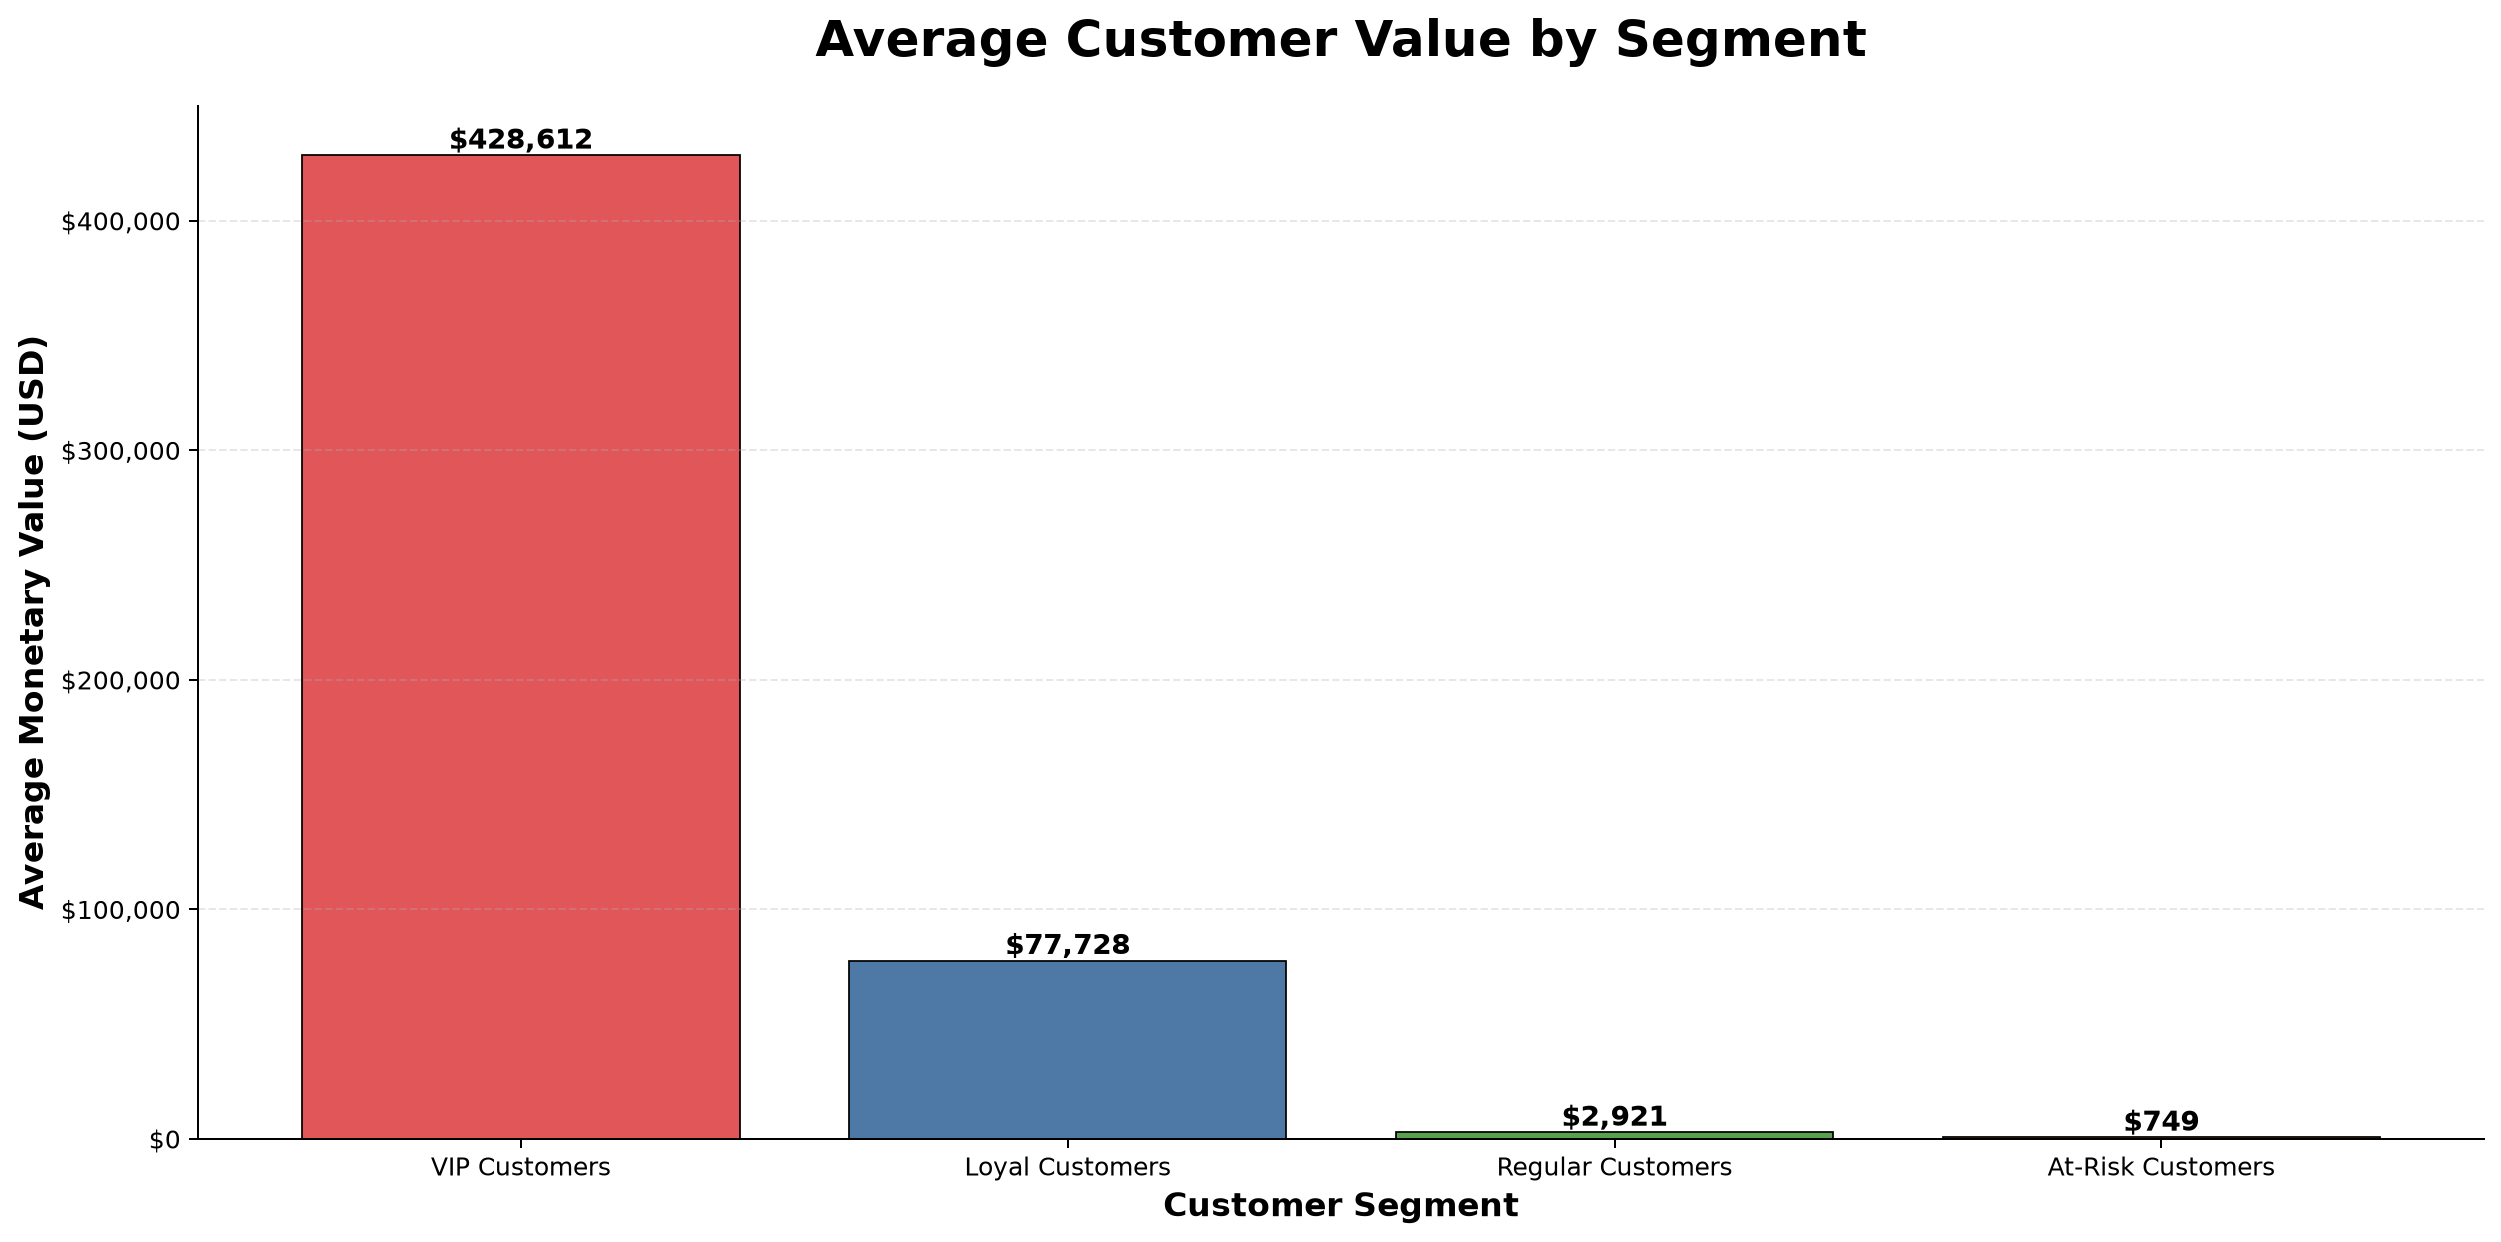

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_data = (
    segment_summary
    .sort_values("Avg_Monetary", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7), dpi=180)

colors = [
    "#E15759",
    "#4E79A7",
    "#59A14F",
    "#F28E2B"
]

bars = ax.bar(
    plot_data["Segment"],
    plot_data["Avg_Monetary"],
    color=colors,
    edgecolor="black",
    linewidth=0.7
)

for bar in bars:
    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.set_title(
    "Average Customer Value by Segment",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Customer Segment",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Monetary Value (USD)",
    fontsize=13,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Executive Summary

## Key Findings

- **VIP Customers** generate exceptionally high revenue and purchase very frequently. They represent the company's most valuable customer segment.
- **Loyal Customers** consistently purchase and contribute significant long-term revenue.
- **Regular Customers** form a stable customer base with moderate purchasing activity.
- **At-Risk Customers** have not purchased for a long period and require re-engagement strategies.

## Business Recommendations

- Develop exclusive loyalty programs for VIP Customers.
- Offer personalized promotions to Loyal Customers to encourage additional purchases.
- Increase engagement campaigns for Regular Customers to improve purchase frequency.
- Launch win-back campaigns targeting At-Risk Customers through discounts, email marketing, or special offers.

In [29]:
OUTPUT_PATH = Path("../data/processed/customer_segments.csv")

customer_features.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Dataset saved to: {OUTPUT_PATH}")

Dataset saved to: ..\data\processed\customer_segments.csv
